# Enrichments

In [ ]:
# Librairies

# Standard
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
%matplotlib inline


# Chromosomes
chroms = [
    'chrI',
    'chrII',
    'chrIII',
    'chrIV',
    'chrV',
    'chrVI',
    'chrVII',
    'chrVIII',
    'chrIX',
    'chrX',
    'chrXI',
    'chrXII',
    'chrXIII',
    'chrXIV',
    'chrXV',
    'chrXVI'
]


# Nucleosomes :
nuc_data ="/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/mono.midpoint.bigwig"

# Cohesin :
cohe_data="/home/nicolas/Documents/Workspace/nucleo/outputs/NUC"+"/GSM4577764_Mcd1p_WT.bigwig"

# Reading :
data = cohe_data

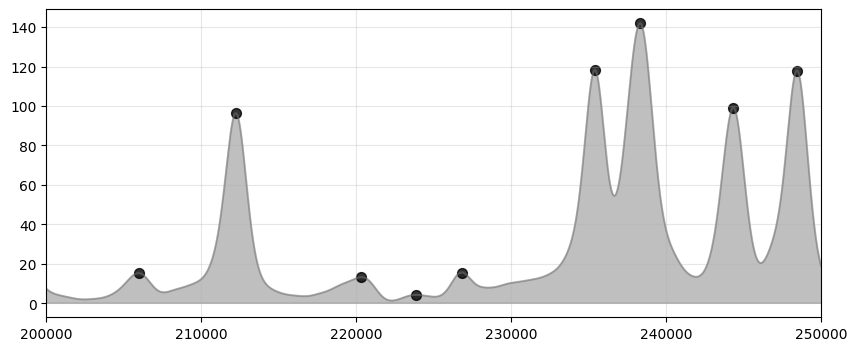

In [9]:
## example loading a bigwig file and plotting the data for a specific chromosome
# load dataframe from bigwig file for chromosome chosen
chrom = 'chrII'
df1 = bioframe.read_bigwig(data, chrom)

#note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')

enrichment_uniform = f(pos_uniform)

# Smooth -> sigma is the smooting parameter
# Based on the biological value : typically, beatween each car there is between 10 and 20 kb

# CARS highly depend on this values !!
# L'algo qui determine les CARs se base sur ces valeurs
# Il faut donc en amont à la main trouver des valeurs qui correspondent

#find peaks in the data using scipy find_peaks function, with a minimum height of min_h and a minimum distance of min_d between peaks.

enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=500)


min_h=1
min_d=10
prominence=0.050
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
xlims = [200_000, 250_000]


# Plot
plt.figure(figsize=(10, 4))
plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(xlims)
plt.grid(True, which="both", alpha=0.30)
plt.show()

(array([4.00025e+05, 5.44430e+04, 1.03210e+04, 2.34600e+03, 5.54000e+02,
        1.60000e+02, 3.90000e+01, 7.00000e+00, 3.00000e+00, 1.00000e+00]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

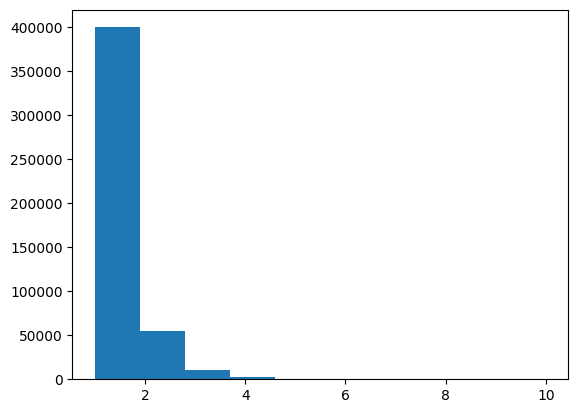

In [ ]:
# Looking just at the raw values
plt.figure(figsize=(8,6))
plt.hist(df1["end"]-df1["start"])
plt.show()

In [ ]:
#create a dataframe with the peaks heights and positions

CARs_df = []
for chrom in chroms[:]:
    df1 = bioframe.read_bigwig(data, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=1000)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    CARs_df.append(chrom_df)
CARs_df = pd.concat(CARs_df, ignore_index=True)


In [ ]:
## create df for cooltools off-diagonal plots using only NN CARS

CARs_df_NN=[]

for chrom in chroms[:]:
    CARs_df_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])


    chrom_mask = (CARs_df["chrom"]==chrom) & (CARs_df["CAR strength"]>10) # Condtiojs ont the dtetcion of CARs
   
    #you may want to add a filter for the CAR strength, for example only consider CARs with strength above a certain threshold
    #strength_mask = CARs_df[chrom_mask]["CAR strength"] > 2

    CARs_df_NN_chrom["chrom1"]=list(CARs_df[chrom_mask][:-1]["chrom"])
    CARs_df_NN_chrom["chrom2"]=list(CARs_df[chrom_mask][1:]["chrom"])

    CARs_df_NN_chrom["start1"]=list(CARs_df[chrom_mask][:-1]["start"])
    CARs_df_NN_chrom["start2"]=list(CARs_df[chrom_mask][1:]["start"]) 

    CARs_df_NN_chrom["end1"]=list(CARs_df[chrom_mask][:-1]["end"])
    CARs_df_NN_chrom["end2"]=list(CARs_df[chrom_mask][1:]["end"])

    CARs_df_NN_chrom["CAR strength1"]=list(CARs_df[chrom_mask][:-1]["CAR strength"])
    CARs_df_NN_chrom["CAR strength2"]=list(CARs_df[chrom_mask][1:]["CAR strength"])

    CARs_df_NN.append(CARs_df_NN_chrom)

CARs_df_NN = pd.concat(CARs_df_NN, ignore_index=True)

In [ ]:


CARs_df_NN.to_parquet("CARs_df_NN.parquet", index=False)
# Saving CARs
# Or savinf nucleosomes 
# Depending on the file we've been reading (cohesin reads of nucleosome reads)

In [43]:
CARs_df_NN
# plt.hist(CARs_df_NN["end2"]-CARs_df_NN["end1"])

,chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2
0,chrI,28578.0,28578.0,11.422373,chrI,30655.0,30655.0,11.147047
1,chrI,30655.0,30655.0,11.147047,chrI,51760.0,51760.0,67.978645
2,chrI,51760.0,51760.0,67.978645,chrI,65256.0,65256.0,21.715945
3,chrI,65256.0,65256.0,21.715945,chrI,80348.0,80348.0,60.766663
4,chrI,80348.0,80348.0,60.766663,chrI,95256.0,95256.0,35.290428
...,...,...,...,...,...,...,...,...
981,chrXVI,885906.0,885906.0,36.332651,chrXVI,893773.0,893773.0,20.768232
982,chrXVI,893773.0,893773.0,20.768232,chrXVI,909629.0,909629.0,14.050758
983,chrXVI,909629.0,909629.0,14.050758,chrXVI,916989.0,916989.0,32.328931
984,chrXVI,916989.0,916989.0,32.328931,chrXVI,930258.0,930258.0,20.321759


# HiC

In [ ]:
import pandas
import cooler
import cooltools
import pandas as pd
from coolpuppy.coolpup import pileup as cpp_pileup
import importlib.metadata as md


#window size NB this is also the minimal distance between CARs that will be considered. If you consider too many low strength CARs that may be a problem
resolution = 1000
flank= 2_000 

clr = cooler.Cooler(
"/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/AD908_G2_mixed.mcool::/resolutions/1000"
)

view_df = pd.DataFrame({
    "chrom": clr.chromnames,
    "start": 0,
    "end": clr.chromsizes.values,
    "name": clr.chromnames
})

cvd = cooltools.expected_cis(
    clr=clr,
    view_df=view_df,
    clr_weight_name=None,
    smooth=True,
    aggregate_smoothed=False,
    nproc=8
)

display(cvd.head())
print(clr.bins().columns)


pup = cpp_pileup(
    clr,
    CARs_df_NN,
    features_format="bedpe",
    flank=flank,
    view_df=view_df,
    expected_df=cvd,
    expected_value_col="count.avg.smoothed",
    clr_weight_name=None,
    nproc=8,
)

INFO:root:creating a Pool of 8 workers


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,count.avg,count.avg.smoothed
0,chrM,chrM,0,0,NaN,86,86,NaN,NaN,NaN
1,chrM,chrM,1,1000,0.0,85,85,NaN,NaN,0.0
2,chrM,chrM,2,2000,0.0,84,84,0.0,0.0,0.0
3,chrM,chrM,3,3000,0.0,83,83,0.0,0.0,0.0
4,chrM,chrM,4,4000,0.0,82,82,0.0,0.0,0.0


Index(['chrom', 'start', 'end'], dtype='object')


INFO:coolpuppy:('chrI', 'chrI'): 11
INFO:coolpuppy:('chrIII', 'chrIII'): 19
INFO:coolpuppy:('chrIX', 'chrIX'): 34
INFO:coolpuppy:('chrVIII', 'chrVIII'): 34
INFO:coolpuppy:('chrVI', 'chrVI'): 15
INFO:coolpuppy:('chrX', 'chrX'): 51
INFO:coolpuppy:('chrXI', 'chrXI'): 43
INFO:coolpuppy:('chrV', 'chrV'): 33
INFO:coolpuppy:('chrXIII', 'chrXIII'): 57
INFO:coolpuppy:('chrXIV', 'chrXIV'): 49
INFO:coolpuppy:('chrXII', 'chrXII'): 72
INFO:coolpuppy:('chrXV', 'chrXV'): 71
INFO:coolpuppy:('chrXVI', 'chrXVI'): 66
INFO:coolpuppy:('chrII', 'chrII'): 55
INFO:coolpuppy:('chrVII', 'chrVII'): 72
INFO:coolpuppy:('chrIV', 'chrIV'): 96
INFO:coolpuppy:Total number of piled up windows: 778


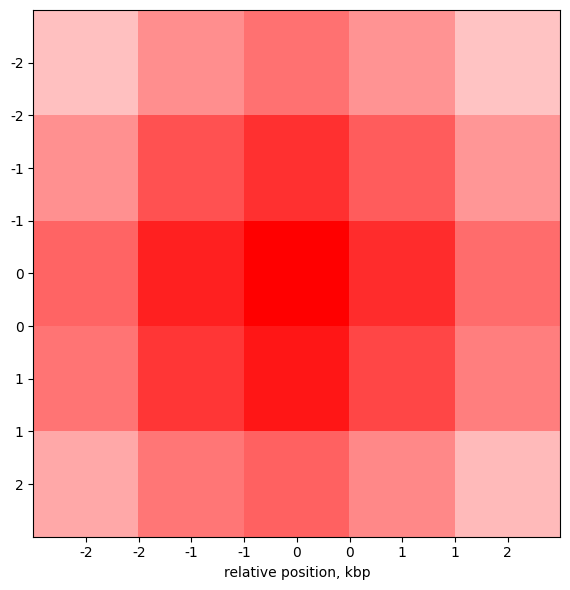

In [45]:
fig, ax = plt.subplots(figsize=(6, 6))
mtx=pup.loc[0, 'data']
im=ax.imshow(
    np.log2((mtx)),
    cmap='bwr',
    vmin=-1,
    vmax=1,
interpolation='none')

ticks_pixels = np.linspace(0, flank*2//resolution,9)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
ax.set(
    xticks=ticks_pixels,
    xticklabels=ticks_kbp,
    yticks=ticks_pixels,
    yticklabels=ticks_kbp,
    xlabel='relative position, kbp'
    )
        
fig.tight_layout()

/tmp/ipykernel_13670/3395831196.py:4: RuntimeWarning: divide by zero encountered in log2
  np.log2(mtx_2),


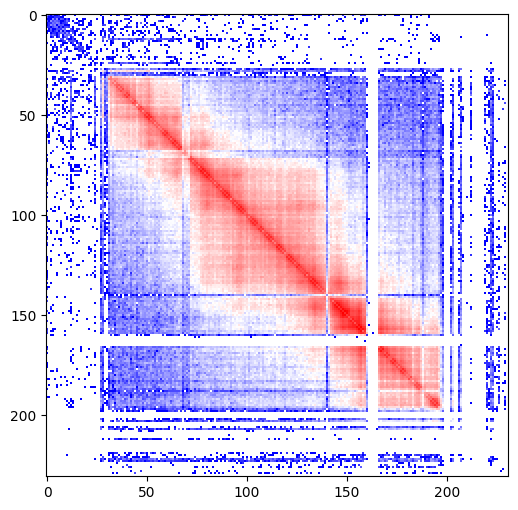

In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
mtx_2=clr.matrix(balance=False).fetch("chrI")
im=ax.imshow(
    np.log2(mtx_2),
    cmap='bwr',
    # vmin=-1,
    # vmax=1,
interpolation='none')

# .